# Drug Review Sentiment Analysis Using Machine Learning

---

## Section 1 — Project Introduction

### What is Sentiment Analysis?

Sentiment analysis (also called opinion mining) is a Natural Language Processing (NLP) technique used to identify and extract subjective information from text — most commonly, whether the expressed opinion is **positive**, **neutral**, or **negative**.

### Why Apply Sentiment Analysis to Drug Reviews?

Patients and caregivers frequently share their experiences with medications on online platforms. These reviews capture a wide range of emotions — relief, frustration, satisfaction, or concern — that can reveal patterns about how people feel about a particular drug. Analysing this sentiment at scale can help:
- Researchers understand broad patient perspectives.
- Healthcare professionals learn about common patient-reported experiences.
- Data scientists practise real-world text classification on a meaningful dataset.

### Objective

This project builds a machine-learning pipeline that:
1. Loads the Drug Reviews (Druglib.com) dataset.
2. Derives sentiment labels (Positive / Neutral / Negative) from numeric ratings.
3. Preprocesses the combined review text.
4. Trains and compares several traditional ML classifiers using TF-IDF features.
5. Selects and saves the best model for use in a Streamlit web application.

### Important Disclaimer

> ⚠️ **This project analyses user-written opinions and does NOT determine whether a medication is medically safe, effective, or clinically appropriate for any patient.** Sentiment expressed in a review reflects a personal experience and is not clinical evidence. Do not use the outputs of this project to make any health or treatment decisions.

---
## Section 2 — Import Libraries

In [1]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.sparse
import sklearn

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import joblib

warnings.filterwarnings('ignore')

# Reproducibility seed
RANDOM_STATE = 42

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Section 3 — Load Dataset

The dataset files are located in the `data/` folder relative to the project root.  
We inspect shape, columns, dtypes, missing values, duplicates, and sample records before assuming anything.

In [2]:
# ---------------------------------------------------------------------------
# Resolve paths relative to the project root (one level above this notebook)
# ---------------------------------------------------------------------------
# Works whether Jupyter was started in the project root or in notebooks/
CWD          = os.getcwd()
PROJECT_ROOT = CWD if os.path.isdir(os.path.join(CWD, 'data')) else os.path.abspath(os.path.join(CWD, '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data')
MODELS_DIR   = os.path.join(PROJECT_ROOT, 'models')

TRAIN_PATH = os.path.join(DATA_DIR, 'train.tsv')
TEST_PATH  = os.path.join(DATA_DIR, 'test.tsv')

for path in [TRAIN_PATH, TEST_PATH]:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Required file not found: {path}\n"
            "Please ensure train.tsv and test.tsv are placed in the data/ folder."
        )

os.makedirs(MODELS_DIR, exist_ok=True)

# Load with index_col=0 because the first column is an unnamed row index
train_raw = pd.read_csv(TRAIN_PATH, sep='\t', index_col=0)
test_raw  = pd.read_csv(TEST_PATH,  sep='\t', index_col=0)

print('=== TRAIN SET ===')
print(f'Shape : {train_raw.shape}')
print(f'Columns: {train_raw.columns.tolist()}')
print()
print('=== TEST SET ===')
print(f'Shape : {test_raw.shape}')
print(f'Columns: {test_raw.columns.tolist()}')

=== TRAIN SET ===
Shape : (3107, 8)
Columns: ['urlDrugName', 'rating', 'effectiveness', 'sideEffects', 'condition', 'benefitsReview', 'sideEffectsReview', 'commentsReview']

=== TEST SET ===
Shape : (1036, 8)
Columns: ['urlDrugName', 'rating', 'effectiveness', 'sideEffects', 'condition', 'benefitsReview', 'sideEffectsReview', 'commentsReview']


In [3]:
# Inspect data types
print('=== TRAIN DTYPES ===')
print(train_raw.dtypes)
print()

# Missing values
print('=== TRAIN MISSING VALUES ===')
print(train_raw.isnull().sum())
print()

# Duplicate rows
print(f'Train duplicate rows: {train_raw.duplicated().sum()}')
print(f'Test  duplicate rows: {test_raw.duplicated().sum()}')

=== TRAIN DTYPES ===
urlDrugName            str
rating               int64
effectiveness          str
sideEffects            str
condition              str
benefitsReview         str
sideEffectsReview      str
commentsReview         str
dtype: object

=== TRAIN MISSING VALUES ===
urlDrugName           0
rating                0
effectiveness         0
sideEffects           0
condition             1
benefitsReview       18
sideEffectsReview    75
commentsReview       12
dtype: int64

Train duplicate rows: 31
Test  duplicate rows: 4


In [4]:
# Sample records
train_raw.head(3)

,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...


---
## Section 4 — Data Exploration

The dataset has three separate review columns: `benefitsReview`, `sideEffectsReview`, and `commentsReview`.  
These will be concatenated into a single `review` field in the preprocessing step.

In [5]:
print(f'Training samples : {len(train_raw):,}')
print(f'Test samples     : {len(test_raw):,}')
print()
print(f'Unique drugs (train)      : {train_raw["urlDrugName"].nunique()}')
print(f'Unique conditions (train) : {train_raw["condition"].nunique()}')
print()
print('Rating distribution (train):')
print(train_raw['rating'].value_counts().sort_index())

Training samples : 3,107
Test samples     : 1,036

Unique drugs (train)      : 502
Unique conditions (train) : 1426

Rating distribution (train):
rating
1     305
2     103
3     146
4     107
5     159
6     157
7     350
8     558
9     480
10    742
Name: count, dtype: int64


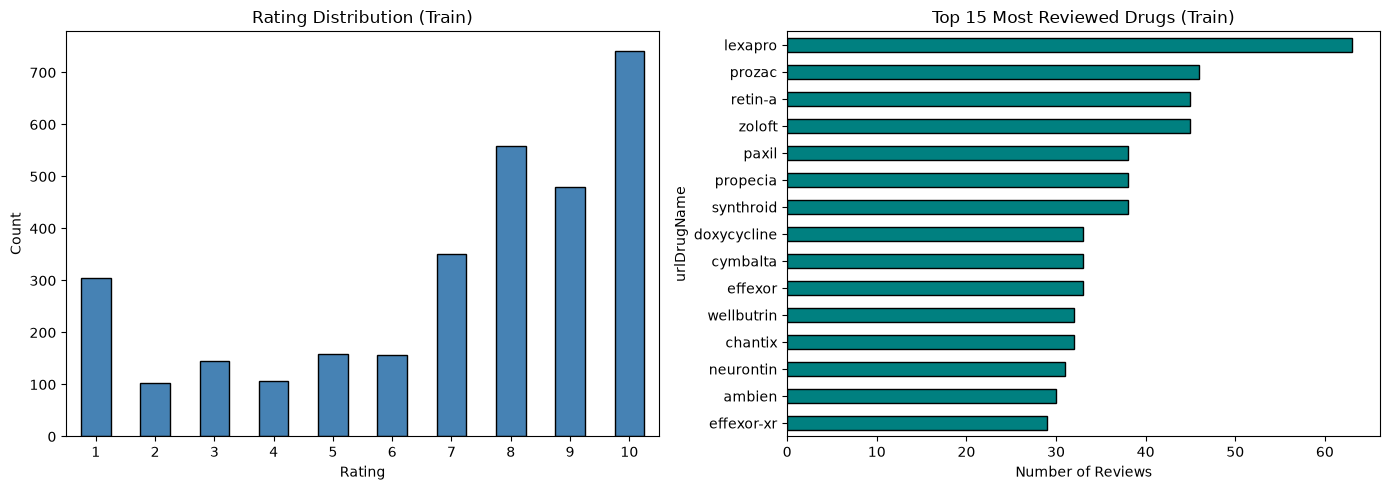

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution
train_raw['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Rating Distribution (Train)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Top 15 most reviewed drugs
top_drugs = train_raw['urlDrugName'].value_counts().head(15)
top_drugs.sort_values().plot(kind='barh', ax=axes[1], color='teal', edgecolor='black')
axes[1].set_title('Top 15 Most Reviewed Drugs (Train)')
axes[1].set_xlabel('Number of Reviews')

plt.tight_layout()
plt.show()

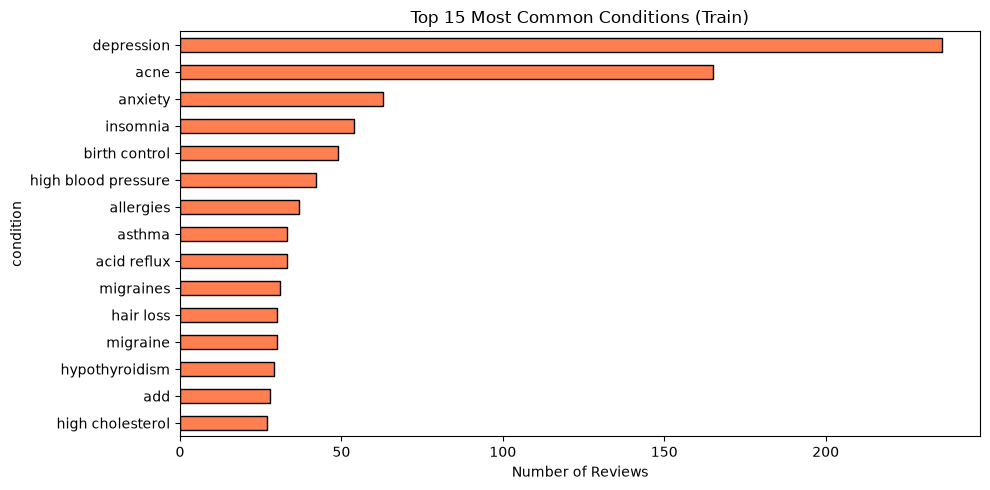

In [7]:
# Top 15 most common conditions
plt.figure(figsize=(10, 5))
train_raw['condition'].value_counts().head(15).sort_values().plot(
    kind='barh', color='coral', edgecolor='black'
)
plt.title('Top 15 Most Common Conditions (Train)')
plt.xlabel('Number of Reviews')
plt.tight_layout()
plt.show()

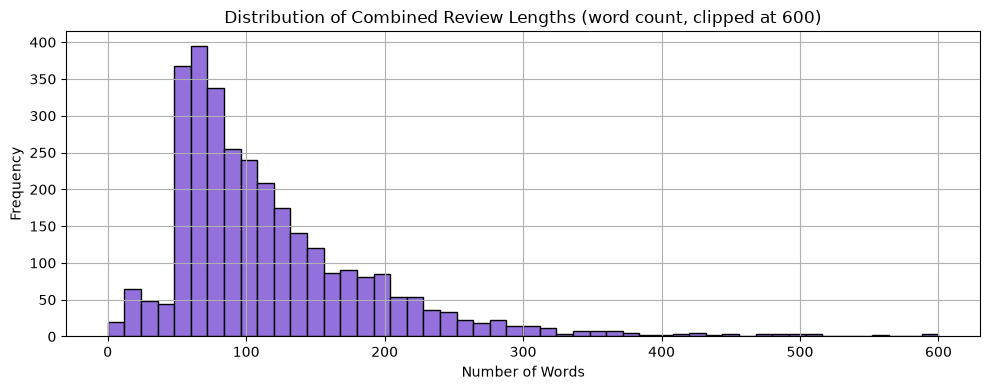

Mean review length : 117.9 words
Median             : 96 words
Max                : 873 words


In [8]:
# Review length distribution — combine the three text columns first for a rough look
combined_text = (
    train_raw[['benefitsReview', 'sideEffectsReview', 'commentsReview']]
    .fillna('')
    .apply(lambda row: ' '.join(row.values), axis=1)
)
review_lengths = combined_text.str.split().str.len()

plt.figure(figsize=(10, 4))
review_lengths.clip(upper=600).hist(bins=50, color='mediumpurple', edgecolor='black')
plt.title('Distribution of Combined Review Lengths (word count, clipped at 600)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'Mean review length : {review_lengths.mean():.1f} words')
print(f'Median             : {review_lengths.median():.0f} words')
print(f'Max                : {review_lengths.max()} words')

---
## Section 5 — Data Cleaning

We combine the three review columns and apply a lightweight cleaning pipeline suitable for TF-IDF.

### Why preserve negation words?

Negation words such as *not*, *no*, *never*, *didn't*, *doesn't* are critical carriers of sentiment polarity.  
Removing them would flip or destroy the meaning: "did **not** help" → "did help".  
Therefore **no stop-word removal is applied at all**, so every negation word stays in the text.

### Missing text and duplicates

- A missing review column is treated as an empty string. (It must never become the literal word `nan`, which would leak "this column was left blank" into the features.)
- Exact duplicate reviews are dropped from the training data, and any test review that also appears in the training data is dropped from the test data. Otherwise the same text can sit on both sides of a split and inflate the scores.

In [9]:
def clean_text(text: str) -> str:
    """Light-touch text cleaning for TF-IDF sentiment analysis.

    Steps:
        1. Handle non-string input.
        2. Convert to lowercase.
        3. Remove HTML tags.
        4. Remove URLs.
        5. Remove punctuation (keep apostrophes in contractions).
        6. Normalize whitespace.

    NOTE: app.py has a copy of this function. Keep both identical.
    """
    if not isinstance(text, str):
        return ''

    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)          # remove HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text) # remove URLs
    text = re.sub(r"[^a-z0-9'\s]", ' ', text)     # keep letters, digits, apostrophes
    text = re.sub(r"\s+", ' ', text).strip()       # normalize whitespace
    return text


def build_combined_review(row: pd.Series) -> str:
    """Concatenate the three review columns into one text (missing -> skipped)."""
    parts = [row[c] for c in REVIEW_COLS if isinstance(row[c], str) and row[c].strip()]
    return ' '.join(parts)


def preprocess_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Apply full preprocessing pipeline to a raw dataframe."""
    df = df.copy()
    df['review']       = df.apply(build_combined_review, axis=1)
    df['clean_review'] = df['review'].apply(clean_text)
    # Drop rows where clean_review is empty after cleaning
    df = df[df['clean_review'] != ''].reset_index(drop=True)
    return df


REVIEW_COLS = ['benefitsReview', 'sideEffectsReview', 'commentsReview']
print('Preprocessing functions defined.')

Preprocessing functions defined.


In [10]:
# Apply to train and test
train_df = preprocess_dataframe(train_raw)
test_df  = preprocess_dataframe(test_raw)
n_train_before, n_test_before = len(train_df), len(test_df)

# Remove exact duplicate reviews; keep test rows that are NOT already in train
train_df = train_df.drop_duplicates(subset='clean_review').reset_index(drop=True)
test_df  = test_df.drop_duplicates(subset='clean_review')
test_df  = test_df[~test_df['clean_review'].isin(set(train_df['clean_review']))].reset_index(drop=True)

print(f'Train: {n_train_before} -> {len(train_df)} after removing duplicates')
print(f'Test : {n_test_before} -> {len(test_df)} after removing duplicates and train overlap')

Train: 3106 -> 3075 after removing duplicates
Test : 1036 -> 1016 after removing duplicates and train overlap


In [11]:
# Show a few examples: original review → cleaned review
examples = train_df[['review', 'clean_review']].head(4)
for i, row in examples.iterrows():
    print(f'--- Example {i+1} ---')
    print(f'ORIGINAL : {row["review"][:300]}')
    print(f'CLEANED  : {row["clean_review"][:300]}')
    print()

--- Example 1 ---
ORIGINAL : slowed the progression of left ventricular dysfunction into overt heart failure 
alone or with other agents in the managment of hypertension 
mangagement of congestive heart failur cough, hypotension , proteinuria, impotence , renal failure , angina pectoris , tachycardia , eosinophilic pneumoni
CLEANED  : slowed the progression of left ventricular dysfunction into overt heart failure alone or with other agents in the managment of hypertension mangagement of congestive heart failur cough hypotension proteinuria impotence renal failure angina pectoris tachycardia eosinophilic pneumonitis tastes disturb

--- Example 2 ---
ORIGINAL : Although this type of birth control has more cons than pros, it did help with my cramps. It's also effective with the prevention of pregnancy. (Along with use of condoms as well) Heavy Cycle, Cramps, Hot Flashes, Fatigue, Long Lasting Cycles. It's only been 5 1/2 months, but i'm concidering changing
CLEANED  : although this type o

---
## Section 6 — Create Sentiment Labels

We map the numeric `rating` (1–10) to a sentiment category:

| Rating | Sentiment |
|--------|-----------|
| 1 – 4  | Negative  |
| 5 – 6  | Neutral   |
| 7 – 10 | Positive  |

The `rating` column itself is **not** used as a model input feature — only the review text is.

In [12]:
def rating_to_sentiment(rating) -> str:
    """Map a numeric rating (1-10) to a sentiment label."""
    try:
        r = int(rating)
    except (ValueError, TypeError):
        return None
    if r <= 4:
        return 'Negative'
    elif r <= 6:
        return 'Neutral'
    else:
        return 'Positive'


train_df['sentiment'] = train_df['rating'].apply(rating_to_sentiment)
test_df['sentiment']  = test_df['rating'].apply(rating_to_sentiment)

# Drop rows with unresolvable ratings
train_df = train_df.dropna(subset=['sentiment']).reset_index(drop=True)
test_df  = test_df.dropna(subset=['sentiment']).reset_index(drop=True)

print('=== TRAIN SENTIMENT DISTRIBUTION ===')
counts = train_df['sentiment'].value_counts()
pct    = train_df['sentiment'].value_counts(normalize=True) * 100
dist_df = pd.DataFrame({'Count': counts, 'Percentage': pct.round(1)})
print(dist_df)
print()
print('=== TEST SENTIMENT DISTRIBUTION ===')
print(test_df['sentiment'].value_counts())

=== TRAIN SENTIMENT DISTRIBUTION ===
           Count  Percentage
sentiment                   
Positive    2108        68.6
Negative     659        21.4
Neutral      308        10.0

=== TEST SENTIMENT DISTRIBUTION ===
sentiment
Positive    660
Negative    238
Neutral     118
Name: count, dtype: int64


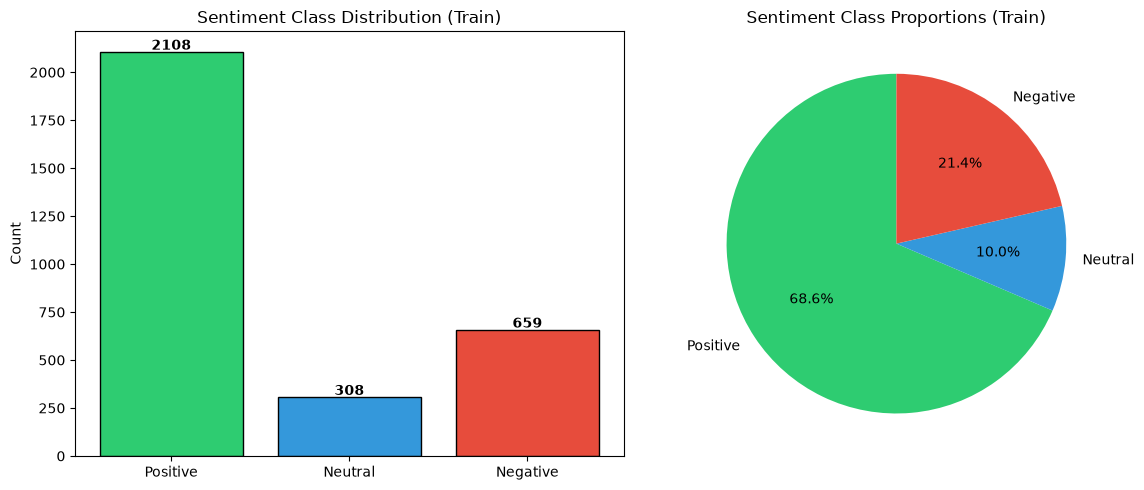


Class imbalance note: largest class = 68.6%, smallest = 10.0%
⚠️  Moderate to high class imbalance detected. Use weighted/macro metrics during evaluation.


In [13]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order = ['Positive', 'Neutral', 'Negative']
colors = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}
color_list = [colors[s] for s in order]

# Count bar chart
counts_ordered = train_df['sentiment'].value_counts().reindex(order)
axes[0].bar(order, counts_ordered.values, color=color_list, edgecolor='black')
axes[0].set_title('Sentiment Class Distribution (Train)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts_ordered.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    counts_ordered.values,
    labels=order,
    colors=color_list,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Sentiment Class Proportions (Train)')

plt.tight_layout()
plt.show()

# Class imbalance note
max_pct = pct.max()
min_pct = pct.min()
print(f'\nClass imbalance note: largest class = {max_pct:.1f}%, smallest = {min_pct:.1f}%')
if max_pct / min_pct > 2:
    print('⚠️  Moderate to high class imbalance detected. Use weighted/macro metrics during evaluation.')
else:
    print('✅  Classes are reasonably balanced.')

---
## Section 7 — Train / Validation Split

We split the **training set only** into training and validation partitions (80/20, stratified).  
The test set (`test.tsv`) remains untouched until final evaluation.

In [14]:
X_all = train_df['clean_review']
y_all = train_df['sentiment']

X_train, X_validation, y_train, y_validation = train_test_split(
    X_all, y_all,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_all
)

print(f'X_train      : {X_train.shape[0]} samples')
print(f'X_validation : {X_validation.shape[0]} samples')
print()
print('Train split sentiment distribution:')
print(y_train.value_counts())
print()
print('Validation split sentiment distribution:')
print(y_validation.value_counts())

X_train      : 2460 samples
X_validation : 615 samples

Train split sentiment distribution:
sentiment
Positive    1687
Negative     527
Neutral      246
Name: count, dtype: int64

Validation split sentiment distribution:
sentiment
Positive    421
Negative    132
Neutral      62
Name: count, dtype: int64


---
## Section 8 — TF-IDF Vectorization

We fit the `TfidfVectorizer` **only on the training split** to prevent data leakage.  

### Why does fitting on training only prevent data leakage?

If we fit the vectorizer on the full dataset (including validation/test), the model gains indirect knowledge of vocabulary and document-frequency statistics from data it is supposed to have never seen. This inflates evaluation scores and gives a false sense of performance. By fitting only on `X_train`, the vocabulary and IDF weights are purely derived from training data.

In [15]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=50000
)

# Fit ONLY on training data, then transform all splits
X_train_tfidf      = tfidf.fit_transform(X_train)
X_validation_tfidf = tfidf.transform(X_validation)

# Test set transformed but NOT used until final evaluation
X_test_tfidf = tfidf.transform(test_df['clean_review'])
y_test       = test_df['sentiment']

print(f'TF-IDF vocabulary size : {len(tfidf.vocabulary_):,} features')
print(f'X_train_tfidf shape    : {X_train_tfidf.shape}')
print(f'X_validation_tfidf     : {X_validation_tfidf.shape}')
print(f'X_test_tfidf           : {X_test_tfidf.shape}')

TF-IDF vocabulary size : 33,513 features
X_train_tfidf shape    : (2460, 33513)
X_validation_tfidf     : (615, 33513)
X_test_tfidf           : (1016, 33513)


### Baseline models (concatenated text)

The helpers below are used for **both** feature strategies, so the comparison in Section 9 is fair.

In [16]:
LABEL_ORDER = ['Positive', 'Neutral', 'Negative']   # display order only


def make_models():
    """Fresh, untrained copies of the three classifiers."""
    return {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'
        ),
        'Multinomial Naive Bayes': MultinomialNB(),
        'Linear SVM': LinearSVC(
            max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced'
        ),
    }


def evaluate_model(model, X_val, y_val):
    """Return a dict of validation metrics."""
    y_pred = model.predict(X_val)
    return {
        'Accuracy'      : accuracy_score(y_val, y_pred),
        'Precision (W)' : precision_score(y_val, y_pred, average='weighted', zero_division=0),
        'Recall (W)'    : recall_score(y_val, y_pred,    average='weighted', zero_division=0),
        'F1 (Weighted)' : f1_score(y_val, y_pred,        average='weighted', zero_division=0),
        'F1 (Macro)'    : f1_score(y_val, y_pred,        average='macro',    zero_division=0),
    }


def fit_and_score(X_tr, X_val):
    """Train all three classifiers on X_tr; score them on X_val."""
    trained, scores = {}, {}
    for name, model in make_models().items():
        model.fit(X_tr, y_train)
        trained[name] = model
        scores[name]  = evaluate_model(model, X_val, y_validation)
    return trained, scores


trained_concat, results_concat = fit_and_score(X_train_tfidf, X_validation_tfidf)
print('Baseline (concatenated text) models trained.')

Baseline (concatenated text) models trained.


---
## Section 9 — Per-Column TF-IDF Feature Union

The dataset contains three semantically distinct review columns:

| Column | What it captures |
|---|---|
| `benefitsReview` | What the drug helped with — typically positive language |
| `sideEffectsReview` | Side effects experienced — often negative language |
| `commentsReview` | Overall opinion / recommendation — mixed sentiment |

**Hypothesis:** Training a separate TF-IDF vectorizer on each column and then combining (hstacking) the resulting sparse matrices may capture column-specific vocabulary patterns better than treating all text as one undifferentiated block.

We build both feature representations and compare them head-to-head using the same three classifiers.  
The better strategy is then carried forward into the final model.

In [17]:
REVIEW_COLS = ['benefitsReview', 'sideEffectsReview', 'commentsReview']

# ---------------------------------------------------------------------------
# Build the per-column split datasets (clean each column individually)
# ---------------------------------------------------------------------------
def get_col_splits(df, col):
    """Return the cleaned text of a single review column for every row."""
    return df[col].fillna('').apply(clean_text)


# Train-split indices align with X_train / X_validation created earlier
train_idx = X_train.index
val_idx   = X_validation.index

# Per-column TF-IDF vectorizers (same hyper-params as the baseline vectorizer)
TFIDF_PARAMS = dict(ngram_range=(1, 2), min_df=2, max_df=0.95,
                    sublinear_tf=True, max_features=20000)

col_tfidf = {}   # col_name -> fitted TfidfVectorizer
X_train_col_parts = []
X_val_col_parts   = []
X_test_col_parts  = []

for col in REVIEW_COLS:
    vec = TfidfVectorizer(**TFIDF_PARAMS)
    col_train_text = get_col_splits(train_df, col).iloc[train_df.index.get_indexer(train_idx)]
    col_val_text   = get_col_splits(train_df, col).iloc[train_df.index.get_indexer(val_idx)]
    col_test_text  = get_col_splits(test_df,  col)

    X_tr = vec.fit_transform(col_train_text)   # fit ONLY on training split
    X_vl = vec.transform(col_val_text)
    X_ts = vec.transform(col_test_text)

    col_tfidf[col] = vec
    X_train_col_parts.append(X_tr)
    X_val_col_parts.append(X_vl)
    X_test_col_parts.append(X_ts)
    print(f'{col}: vocab={len(vec.vocabulary_):,}, train shape={X_tr.shape}')

# Horizontally stack the three sparse matrices
X_train_union = scipy.sparse.hstack(X_train_col_parts, format='csr')
X_val_union   = scipy.sparse.hstack(X_val_col_parts,   format='csr')
X_test_union  = scipy.sparse.hstack(X_test_col_parts,  format='csr')

print(f'\nUnion feature matrix — train : {X_train_union.shape}')
print(f'Union feature matrix — val   : {X_val_union.shape}')
print(f'Union feature matrix — test  : {X_test_union.shape}')

benefitsReview: vocab=12,703, train shape=(2460, 12703)
sideEffectsReview: vocab=10,880, train shape=(2460, 10880)
commentsReview: vocab=16,034, train shape=(2460, 16034)

Union feature matrix — train : (2460, 39617)
Union feature matrix — val   : (615, 39617)
Union feature matrix — test  : (1016, 39617)


In [18]:
# ---------------------------------------------------------------------------
# Train the same three classifiers on the UNION features and compare
# ---------------------------------------------------------------------------
trained_union, results_union = fit_and_score(X_train_union, X_val_union)

print('=== BASELINE (concatenated text TF-IDF) ===')
print(pd.DataFrame(results_concat).T.round(4).to_string())
print()
print('=== PER-COLUMN FEATURE UNION ===')
print(pd.DataFrame(results_union).T.round(4).to_string())

# Better strategy = higher best weighted F1 across all models (ties go to the simpler baseline)
best_baseline_f1 = max(v['F1 (Weighted)'] for v in results_concat.values())
best_union_f1    = max(v['F1 (Weighted)'] for v in results_union.values())

if best_union_f1 > best_baseline_f1:
    FEATURE_STRATEGY = 'union'
    print(f'\nPer-column union wins (F1={best_union_f1:.4f} vs baseline {best_baseline_f1:.4f})')
else:
    FEATURE_STRATEGY = 'concat'
    print(f'\nConcatenated-text baseline wins (F1={best_baseline_f1:.4f} vs union {best_union_f1:.4f})')

print(f'Feature strategy for final model: {FEATURE_STRATEGY}')

=== BASELINE (concatenated text TF-IDF) ===
                         Accuracy  Precision (W)  Recall (W)  F1 (Weighted)  F1 (Macro)
Logistic Regression        0.7252         0.6893      0.7252         0.7028      0.5021
Multinomial Naive Bayes    0.6846         0.4686      0.6846         0.5564      0.2709
Linear SVM                 0.7577         0.7092      0.7577         0.7118      0.4878

=== PER-COLUMN FEATURE UNION ===
                         Accuracy  Precision (W)  Recall (W)  F1 (Weighted)  F1 (Macro)
Logistic Regression        0.7561         0.7067      0.7561         0.7271      0.5197
Multinomial Naive Bayes    0.6959         0.6886      0.6959         0.5818      0.3063
Linear SVM                 0.7837         0.7556      0.7837         0.7483      0.5531

Per-column union wins (F1=0.7483 vs baseline 0.7118)
Feature strategy for final model: union


---
## Section 10 — Compare Models on the Winning Strategy

Three classical ML classifiers were already trained and scored on the **validation set** in Sections 8 and 9:  
1. Logistic Regression  
2. Multinomial Naive Bayes  
3. Linear SVM (`LinearSVC`)

Here we pick the results that belong to the strategy selected in Section 9 and look at them in detail.

In [19]:
if FEATURE_STRATEGY == 'union':
    trained_models, results = trained_union, results_union
    X_val_use = X_val_union
else:
    trained_models, results = trained_concat, results_concat
    X_val_use = X_validation_tfidf

for name, r in results.items():
    print(f'{name}')
    print(f'  Validation Accuracy  : {r["Accuracy"]:.4f}')
    print(f'  Validation F1 (W)    : {r["F1 (Weighted)"]:.4f}')
    print(f'  Validation F1 (Macro): {r["F1 (Macro)"]:.4f}')
    print()

Logistic Regression
  Validation Accuracy  : 0.7561
  Validation F1 (W)    : 0.7271
  Validation F1 (Macro): 0.5197

Multinomial Naive Bayes
  Validation Accuracy  : 0.6959
  Validation F1 (W)    : 0.5818
  Validation F1 (Macro): 0.3063

Linear SVM
  Validation Accuracy  : 0.7837
  Validation F1 (W)    : 0.7483
  Validation F1 (Macro): 0.5531



In [20]:
# Comparison table
results_df = pd.DataFrame(results).T.round(4)
print('=== MODEL COMPARISON (Validation Set) ===')
results_df

=== MODEL COMPARISON (Validation Set) ===


,Accuracy,Precision (W),Recall (W),F1 (Weighted),F1 (Macro)
Logistic Regression,0.7561,0.7067,0.7561,0.7271,0.5197
Multinomial Naive Bayes,0.6959,0.6886,0.6959,0.5818,0.3063
Linear SVM,0.7837,0.7556,0.7837,0.7483,0.5531


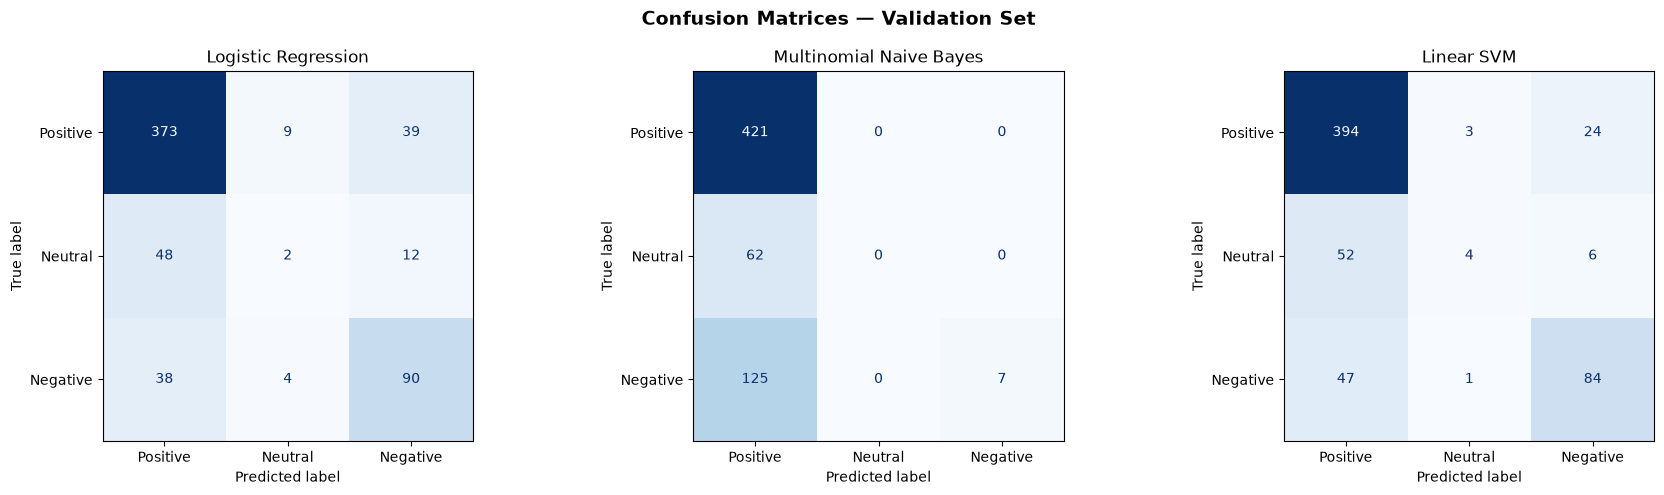

In [21]:
# Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_val_use)
    cm = confusion_matrix(y_validation, y_pred, labels=LABEL_ORDER)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_ORDER)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion Matrices — Validation Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# Detailed classification reports
for name, model in trained_models.items():
    y_pred = model.predict(X_val_use)
    print(f'=== {name} — Classification Report (Validation) ===')
    print(classification_report(y_validation, y_pred, labels=LABEL_ORDER, target_names=LABEL_ORDER, zero_division=0))
    print()

=== Logistic Regression — Classification Report (Validation) ===
              precision    recall  f1-score   support

    Positive       0.81      0.89      0.85       421
     Neutral       0.13      0.03      0.05        62
    Negative       0.64      0.68      0.66       132

    accuracy                           0.76       615
   macro avg       0.53      0.53      0.52       615
weighted avg       0.71      0.76      0.73       615


=== Multinomial Naive Bayes — Classification Report (Validation) ===
              precision    recall  f1-score   support

    Positive       0.69      1.00      0.82       421
     Neutral       0.00      0.00      0.00        62
    Negative       1.00      0.05      0.10       132

    accuracy                           0.70       615
   macro avg       0.56      0.35      0.31       615
weighted avg       0.69      0.70      0.58       615


=== Linear SVM — Classification Report (Validation) ===
              precision    recall  f1-score   

---
## Section 11 — Model Selection

We select the best model based on **weighted F1-score** and **macro F1-score** on the validation set.  
We do **not** use the test set at this stage.

After selecting the model we retrain it on the **full training data** (`train.tsv`) so that no training samples are wasted for validation.

In [23]:
# Select model with the highest weighted F1
best_model_name = max(results, key=lambda m: results[m]['F1 (Weighted)'])
print(f'Selected model: {best_model_name}')
print(f'  Validation F1 (Weighted): {results[best_model_name]["F1 (Weighted)"]:.4f}')
print(f'  Validation F1 (Macro)   : {results[best_model_name]["F1 (Macro)"]:.4f}')

Selected model: Linear SVM
  Validation F1 (Weighted): 0.7483
  Validation F1 (Macro)   : 0.5531


In [24]:
# Retrain the selected model on the COMPLETE training dataset
y_train_full = train_df['sentiment']

if FEATURE_STRATEGY == 'union':
    # Per-column union: refit each column-vectorizer on full training data
    col_tfidf_final = {}
    X_full_parts = []
    for col in REVIEW_COLS:
        vec = TfidfVectorizer(**TFIDF_PARAMS)
        col_text_full = get_col_splits(train_df, col)
        X_full_parts.append(vec.fit_transform(col_text_full))
        col_tfidf_final[col] = vec
        print(f'  {col}: vocab={len(vec.vocabulary_):,}')
    X_train_full_tfidf = scipy.sparse.hstack(X_full_parts, format='csr')
    tfidf_final = None  # not used in union mode
    total_features = X_train_full_tfidf.shape[1]
else:
    # Concatenated text: refit single vectorizer on full training data
    X_train_full = train_df['clean_review']
    tfidf_final = TfidfVectorizer(
        ngram_range=(1, 2), min_df=2, max_df=0.95,
        sublinear_tf=True, max_features=50000
    )
    X_train_full_tfidf = tfidf_final.fit_transform(X_train_full)
    col_tfidf_final = None  # not used in concat mode
    total_features = len(tfidf_final.vocabulary_)

# Instantiate a fresh copy of the selected model class
final_model = make_models()[best_model_name]
final_model.fit(X_train_full_tfidf, y_train_full)

print(f'\nFinal model ({best_model_name}) retrained on {len(y_train_full):,} samples.')
print(f'Feature strategy : {FEATURE_STRATEGY}')
print(f'Total features   : {total_features:,}')

  benefitsReview: vocab=15,291
  sideEffectsReview: vocab=12,974
  commentsReview: vocab=19,444

Final model (Linear SVM) retrained on 3,075 samples.
Feature strategy : union
Total features   : 47,709


---
## Section 12 — Final Test Evaluation

The test set is evaluated **exactly once**, here. Results reflect real-world generalisation performance.

In [25]:
# Transform test data with the winning feature strategy
if FEATURE_STRATEGY == 'union':
    test_parts = [
        col_tfidf_final[col].transform(get_col_splits(test_df, col))
        for col in REVIEW_COLS
    ]
    X_test_final = scipy.sparse.hstack(test_parts, format='csr')
else:
    X_test_final = tfidf_final.transform(test_df['clean_review'])

y_test_pred = final_model.predict(X_test_final)

test_acc    = accuracy_score(y_test, y_test_pred)
test_prec_w = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_rec_w  = recall_score(y_test, y_test_pred,    average='weighted', zero_division=0)
test_f1_w   = f1_score(y_test, y_test_pred,        average='weighted', zero_division=0)
test_f1_m   = f1_score(y_test, y_test_pred,        average='macro',    zero_division=0)

print('=== FINAL TEST SET EVALUATION ===')
print(f'Model         : {best_model_name}')
print(f'Accuracy      : {test_acc:.4f}')
print(f'Precision (W) : {test_prec_w:.4f}')
print(f'Recall (W)    : {test_rec_w:.4f}')
print(f'F1 (Weighted) : {test_f1_w:.4f}')
print(f'F1 (Macro)    : {test_f1_m:.4f}')
print()
print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_test_pred, labels=LABEL_ORDER, target_names=LABEL_ORDER, zero_division=0))

=== FINAL TEST SET EVALUATION ===
Model         : Linear SVM
Accuracy      : 0.7766
Precision (W) : 0.7234
Recall (W)    : 0.7766
F1 (Weighted) : 0.7361
F1 (Macro)    : 0.5458

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Positive       0.81      0.95      0.87       660
     Neutral       0.28      0.04      0.07       118
    Negative       0.72      0.67      0.69       238

    accuracy                           0.78      1016
   macro avg       0.60      0.55      0.55      1016
weighted avg       0.72      0.78      0.74      1016



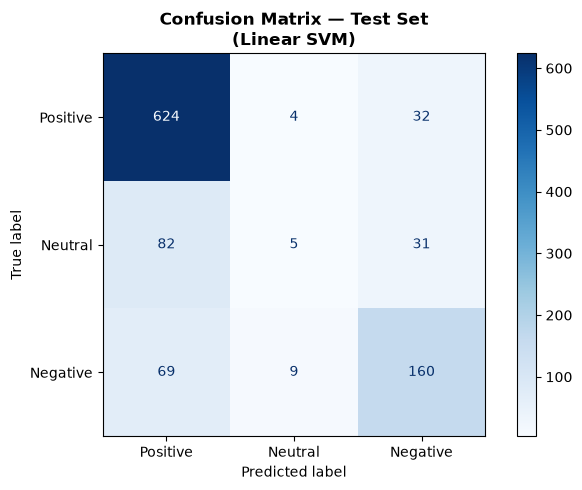

In [26]:
# Confusion matrix — final test
cm_test = confusion_matrix(y_test, y_test_pred, labels=LABEL_ORDER)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=LABEL_ORDER)

fig, ax = plt.subplots(figsize=(7, 5))
disp_test.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix — Test Set\n({best_model_name})', fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# Correct predictions sample
results_test_df = test_df[['review', 'sentiment']].copy()
results_test_df['predicted'] = y_test_pred
results_test_df['correct']   = results_test_df['sentiment'] == results_test_df['predicted']

print('=== CORRECT PREDICTIONS (5 examples) ===')
correct_samples = results_test_df[results_test_df['correct']].sample(5, random_state=RANDOM_STATE)
for _, row in correct_samples.iterrows():
    print(f'  Review    : {str(row["review"])[:150]}...')
    print(f'  Actual    : {row["sentiment"]}  |  Predicted : {row["predicted"]}')
    print()

print('=== INCORRECT PREDICTIONS (5 examples) ===')
incorrect_samples = results_test_df[~results_test_df['correct']].sample(5, random_state=RANDOM_STATE)
for _, row in incorrect_samples.iterrows():
    print(f'  Review    : {str(row["review"])[:150]}...')
    print(f'  Actual    : {row["sentiment"]}  |  Predicted : {row["predicted"]}')
    print()

=== CORRECT PREDICTIONS (5 examples) ===
  Review    : I slept well while on clarithromycin, my fatigue decreased, my intellectual function improved, and my energy level increased. metallic taste in mouth....
  Actual    : Positive  |  Predicted : Positive

  Review    : All symptoms of sinus infection gone by third day. From taking Augmentin before in the past, I knew that the way to avoid the nausea was to take it wi...
  Actual    : Positive  |  Predicted : Positive

  Review    : I was able to relax more than usual, and my mind did not feel like a race car circling a track at 150 miles per hour.  It became easier to focus on th...
  Actual    : Positive  |  Predicted : Positive

  Review    : After about 2 weeks, felt much calmer and less depressed. Stressful situations or emotional distress were experienced less acutely and I was able to d...
  Actual    : Positive  |  Predicted : Positive

  Review    : Helped with sinus congestion and sneezing, and allowed me to be able to breat

### Discussion

**Strengths**
- TF-IDF with bigrams captures common sentiment phrases (e.g. "not helpful", "works great").
- Traditional ML classifiers are fast to train and interpretable.
- Using the full combined review text provides richer signal.

**Weaknesses**
- Bag-of-words ignores word order beyond bigrams; complex negation patterns may be missed.
- Neutral reviews are inherently ambiguous and harder to classify correctly.
- Rating-derived labels are noisy proxies — a 6/10 review might be positive in tone but maps to Neutral.

**Class Imbalance**
- The Positive class dominates; weighted metrics are used to account for this.
- Macro F1 is reported alongside to reflect per-class performance fairly.

**Possible Sources of Error**
- Users may give high ratings while the review text expresses concerns (or vice versa).
- Medical jargon and abbreviations are not normalised.
- The model has no understanding of context or dosage severity.

**Limitations of Rating-Derived Labels**
- Ratings are subjective and vary by reviewer.
- The 5–6 neutral band is narrow and poorly separated from adjacent classes.

> ⚠️ No clinical claims should be made from these results.

---
## Section 13 — Save Model Artifacts

In [28]:
MODEL_PATH           = os.path.join(MODELS_DIR, 'sentiment_model.pkl')
VECTORIZER_PATH      = os.path.join(MODELS_DIR, 'tfidf_vectorizer.pkl')       # concat mode
COL_VECTORIZERS_PATH = os.path.join(MODELS_DIR, 'col_tfidf_vectorizers.pkl')  # union mode
METADATA_PATH        = os.path.join(MODELS_DIR, 'model_metadata.pkl')

# Remove artifacts of the other strategy so the models/ folder never holds a stale mix
for stale in (VECTORIZER_PATH, COL_VECTORIZERS_PATH):
    if os.path.exists(stale):
        os.remove(stale)

joblib.dump(final_model, MODEL_PATH)

if FEATURE_STRATEGY == 'union':
    joblib.dump(col_tfidf_final, COL_VECTORIZERS_PATH)
    vec_params = {col: v.get_params() for col, v in col_tfidf_final.items()}
    print(f'Per-column vectorizers saved: {os.path.relpath(COL_VECTORIZERS_PATH, PROJECT_ROOT)}')
else:
    joblib.dump(tfidf_final, VECTORIZER_PATH)
    vec_params = tfidf_final.get_params()
    print(f'Vectorizer saved : {os.path.relpath(VECTORIZER_PATH, PROJECT_ROOT)}')

metadata = {
    'model_name'         : best_model_name,
    'classes'            : [str(c) for c in final_model.classes_],   # real order used by the model
    'preprocessing'      : 'v2 - lowercase, remove HTML/URLs, keep negation words, no stop-word removal',
    'feature_strategy'   : FEATURE_STRATEGY,
    'tfidf_params'       : vec_params,
    'review_columns'     : REVIEW_COLS,
    'sklearn_version'    : sklearn.__version__,
    'n_train_samples'    : int(len(y_train_full)),
    'n_test_samples'     : int(len(y_test)),
    'validation_f1_weighted': round(results[best_model_name]['F1 (Weighted)'], 4),
    'validation_f1_macro'   : round(results[best_model_name]['F1 (Macro)'], 4),
    'test_accuracy'      : round(test_acc, 4),
    'test_precision_weighted': round(test_prec_w, 4),
    'test_recall_weighted'   : round(test_rec_w, 4),
    'test_f1_weighted'   : round(test_f1_w, 4),
    'test_f1_macro'      : round(test_f1_m, 4),
    'sentiment_mapping'  : {'1-4': 'Negative', '5-6': 'Neutral', '7-10': 'Positive'},
}
joblib.dump(metadata, METADATA_PATH)

print(f'Model saved : {os.path.relpath(MODEL_PATH, PROJECT_ROOT)}')
print(f'Metadata    : {os.path.relpath(METADATA_PATH, PROJECT_ROOT)}')
print(f'Feature strategy used: {FEATURE_STRATEGY}')

Per-column vectorizers saved: models\col_tfidf_vectorizers.pkl
Model saved : models\sentiment_model.pkl
Metadata    : models\model_metadata.pkl
Feature strategy used: union
